# Random Forest Classification

## Assignment: Glass Type Classification

### Objective
To apply Random Forest, Bagging, and Boosting methods for glass classification using the Glass Identification dataset.

### Dataset Description
214 glass samples with 9 chemical composition features. Target: glass Type (1-7).

| Feature | Description |
|---------|-------------|
| RI | Refractive index |
| Na | Sodium |
| Mg | Magnesium |
| Al | Aluminum |
| Si | Silicon |
| K | Potassium |
| Ca | Calcium |
| Ba | Barium |
| Fe | Iron |
| Type | Glass type (1-7) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')

In [2]:
df = pd.read_excel('random forest.xlsx', sheet_name='glass')
print(f'Shape: {df.shape}')
print(f'\nTarget distribution:\n{df["Type"].value_counts().sort_index()}')
print(f'\nNulls: {df.isnull().sum().sum()}')
df.describe()

Shape: (214, 10)

Target distribution:
Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

Nulls: 0


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


## EDA

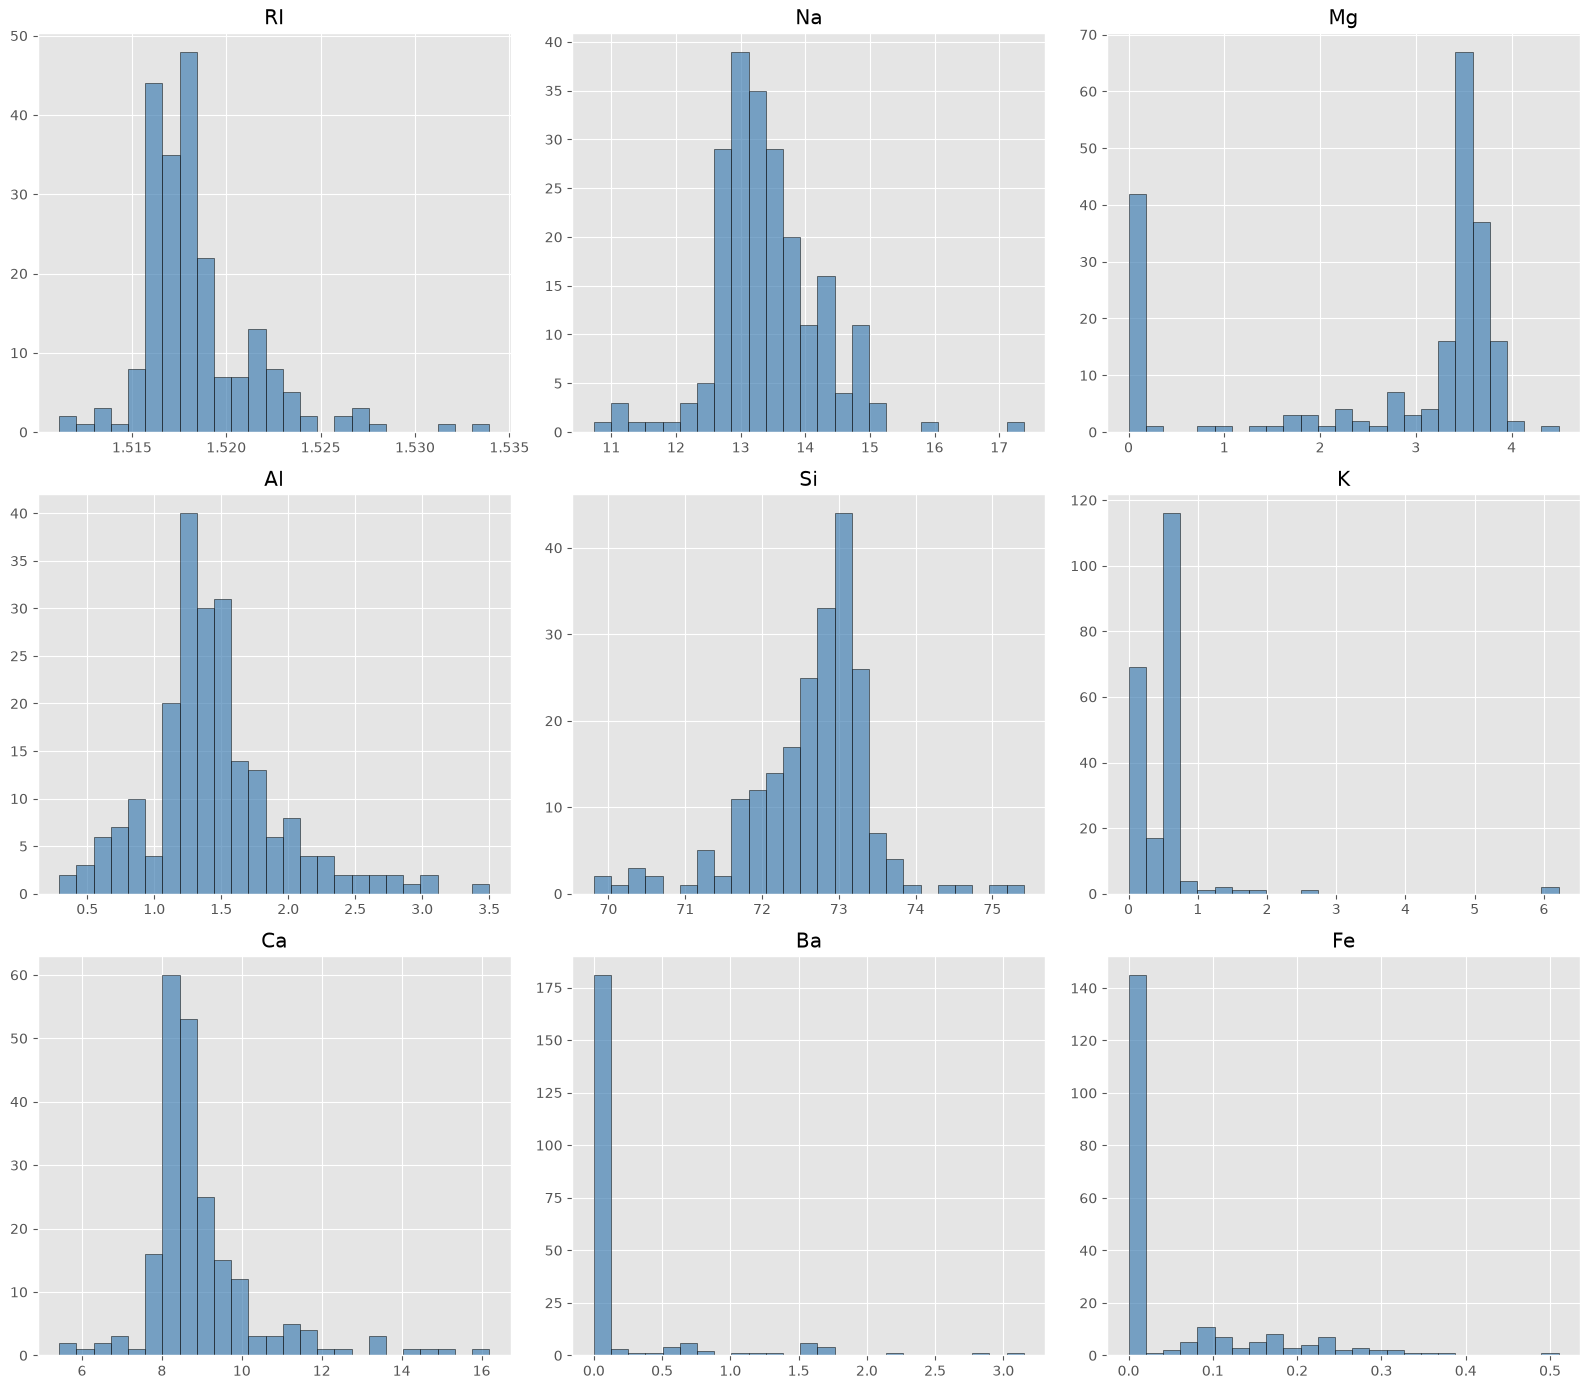

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
feat_cols = [c for c in df.columns if c != 'Type']
for i, col in enumerate(feat_cols):
    axes[i].hist(df[col], bins=25, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

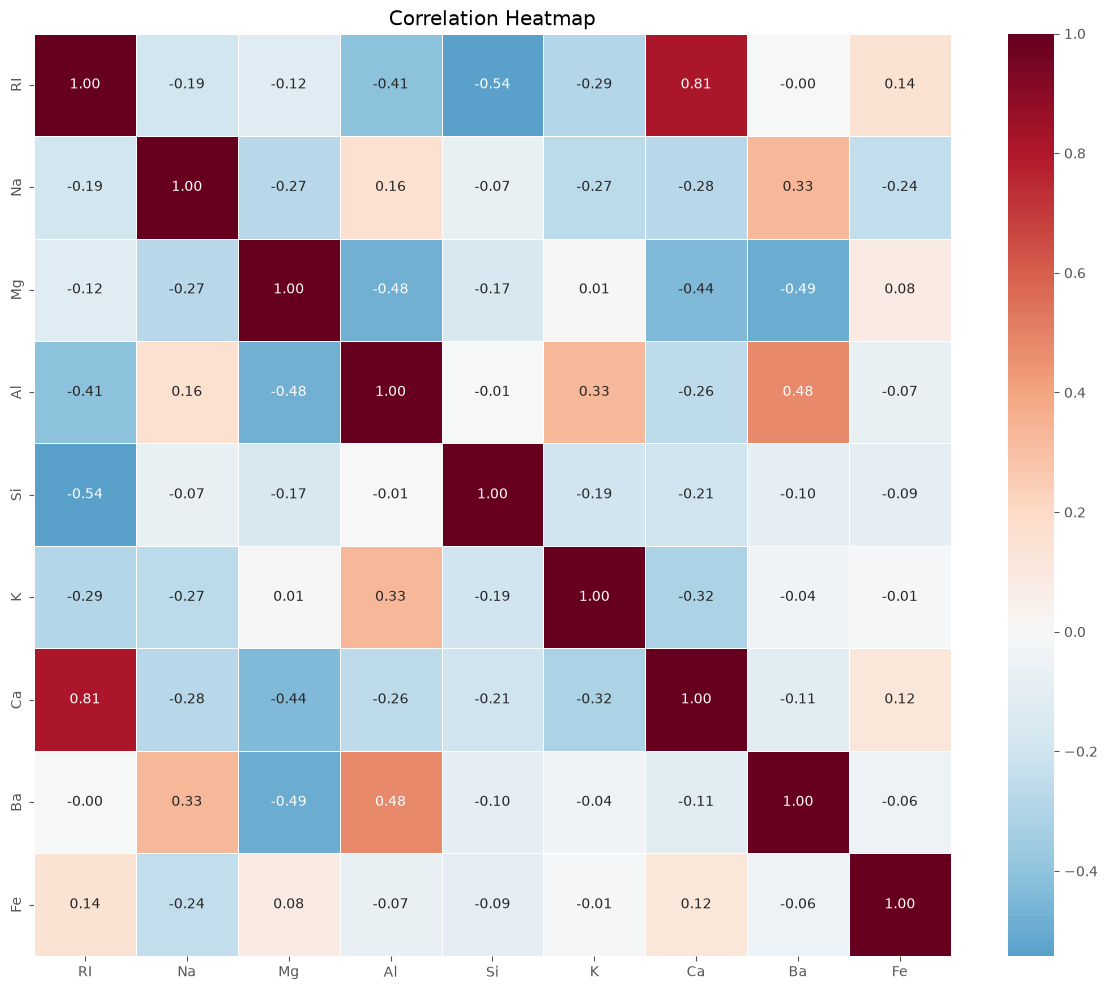

In [4]:
plt.figure(figsize=(12, 10))
corr = df.drop(columns=['Type']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

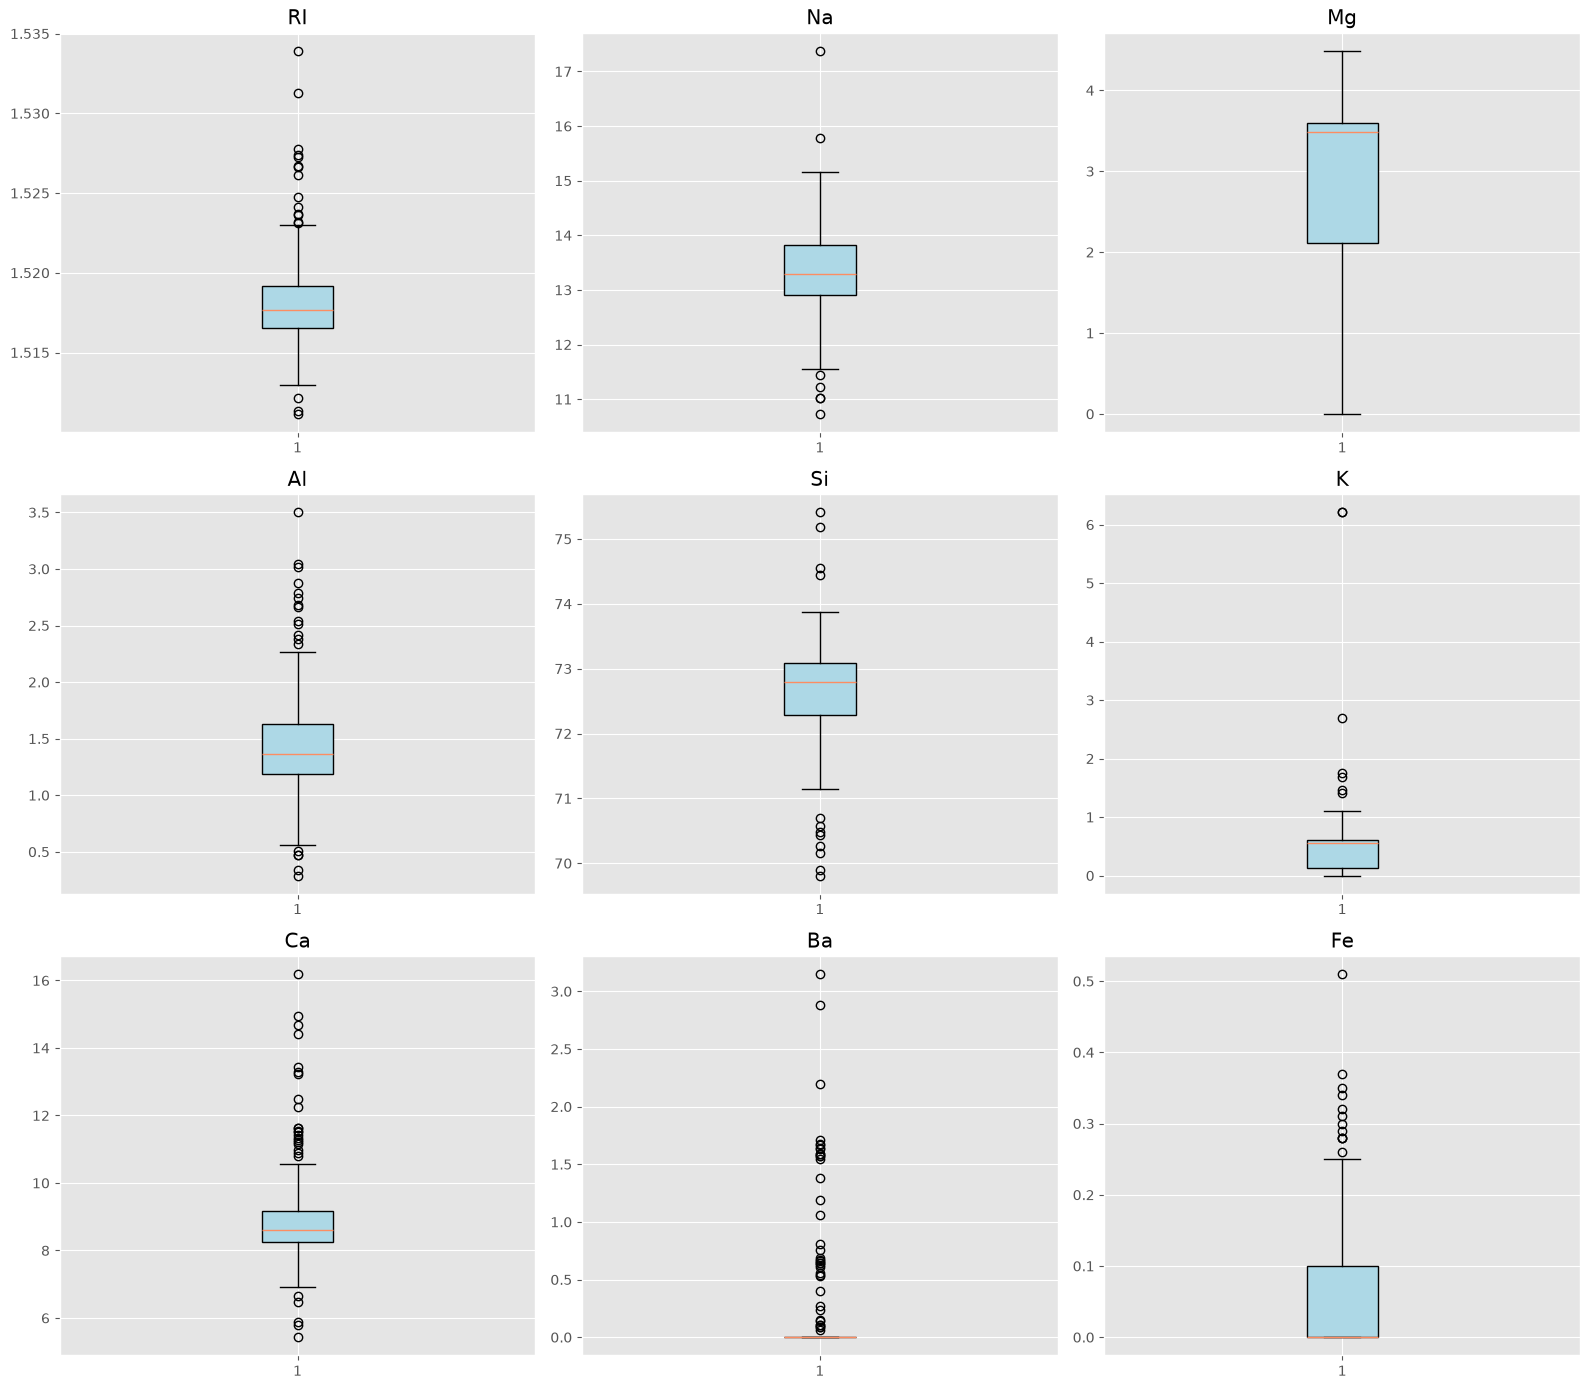

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(feat_cols):
    axes[i].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## Data Preprocessing

In [6]:
X = df.drop(columns=['Type'])
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print(f'Target distribution:\n{y_train.value_counts().sort_index()}')

Train: 171, Test: 43
Target distribution:
Type
1    56
2    61
3    14
5    10
6     7
7    23
Name: count, dtype: int64


## Random Forest Model

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

print('=== RANDOM FOREST ===')
print(f'OOB Score: {rf.oob_score_:.4f}')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision (macro): {precision_score(y_test, y_pred_rf, average="macro"):.4f}')
print(f'Recall (macro): {recall_score(y_test, y_pred_rf, average="macro"):.4f}')
print(f'F1 (macro): {f1_score(y_test, y_pred_rf, average="macro"):.4f}')

=== RANDOM FOREST ===
OOB Score: 0.7485
Test Accuracy: 0.8372
Precision (macro): 0.8796
Recall (macro): 0.8325
F1 (macro): 0.8374


In [8]:
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred_rf))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1       0.76      0.93      0.84        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.88      0.83      0.84        43
weighted avg       0.85      0.84      0.84        43



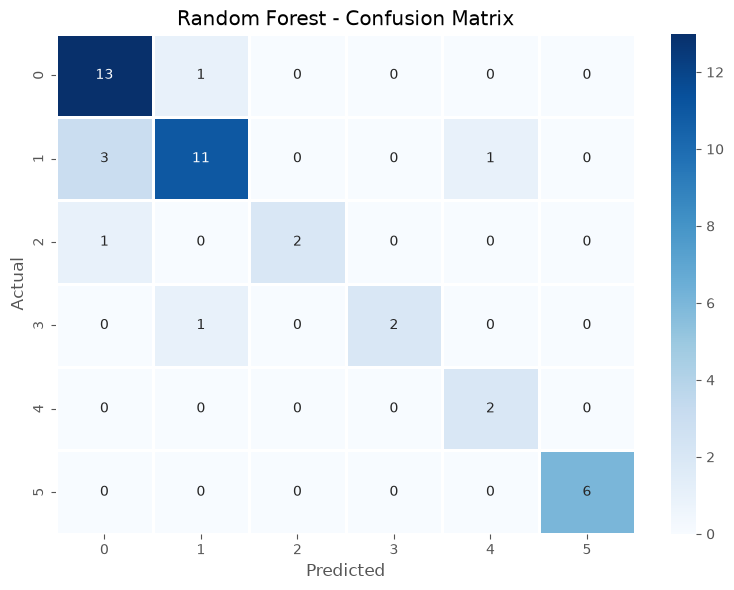

In [9]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

## Feature Importance

Feature  Importance
     Mg    0.174017
     Al    0.157885
     RI    0.128311
     Ca    0.126303
     Na    0.112023
      K    0.088481
     Si    0.085650
     Ba    0.084862
     Fe    0.042468


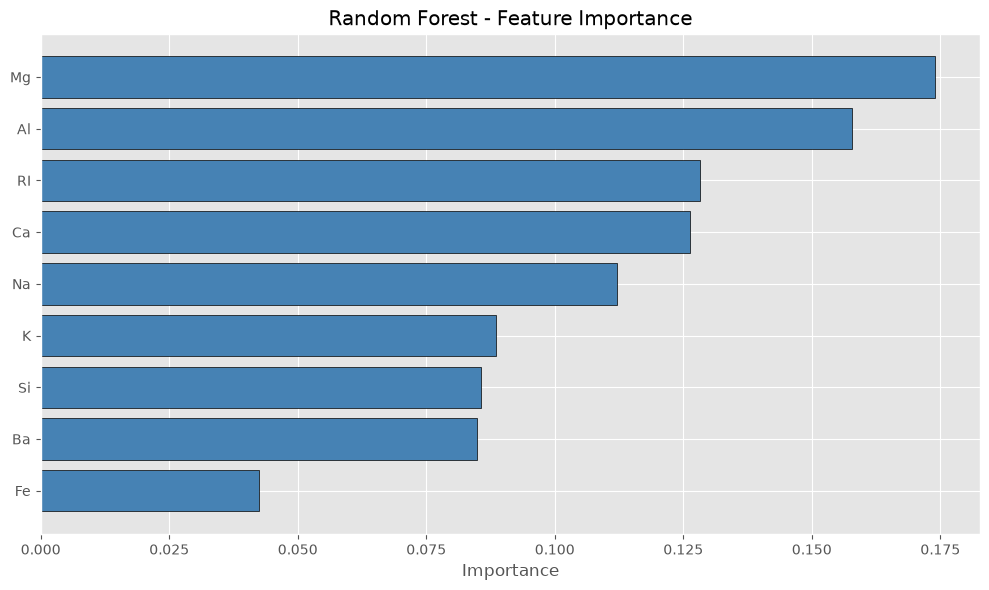

In [10]:
imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
print(imp_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Bagging Classifier

In [11]:
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=100, random_state=42)
bagging.fit(X_train_scaled, y_train)

y_pred_bag = bagging.predict(X_test_scaled)

print('=== BAGGING CLASSIFIER ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_bag):.4f}')
print(f'F1 (macro): {f1_score(y_test, y_pred_bag, average="macro"):.4f}')

=== BAGGING CLASSIFIER ===
Accuracy: 0.8140
F1 (macro): 0.8005


## Boosting Methods

In [12]:
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3, random_state=42), n_estimators=100, random_state=42)
ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)

print('=== ADABOOST ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}')
print(f'F1 (macro): {f1_score(y_test, y_pred_ada, average="macro"):.4f}')

print()
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

print('=== GRADIENT BOOSTING ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'F1 (macro): {f1_score(y_test, y_pred_gb, average="macro"):.4f}')

=== ADABOOST ===
Accuracy: 0.7674
F1 (macro): 0.7559



=== GRADIENT BOOSTING ===
Accuracy: 0.7442
F1 (macro): 0.7470


## Model Comparison

In [13]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Bagging', 'AdaBoost', 'Gradient Boosting'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_bag), accuracy_score(y_test, y_pred_ada), accuracy_score(y_test, y_pred_gb)],
    'F1 (macro)': [f1_score(y_test, y_pred_rf, average='macro'), f1_score(y_test, y_pred_bag, average='macro'), f1_score(y_test, y_pred_ada, average='macro'), f1_score(y_test, y_pred_gb, average='macro')]
})
print(comparison.to_string(index=False))

            Model  Accuracy  F1 (macro)
    Random Forest  0.837209    0.837404
          Bagging  0.813953    0.800507
         AdaBoost  0.767442    0.755889
Gradient Boosting  0.744186    0.747009


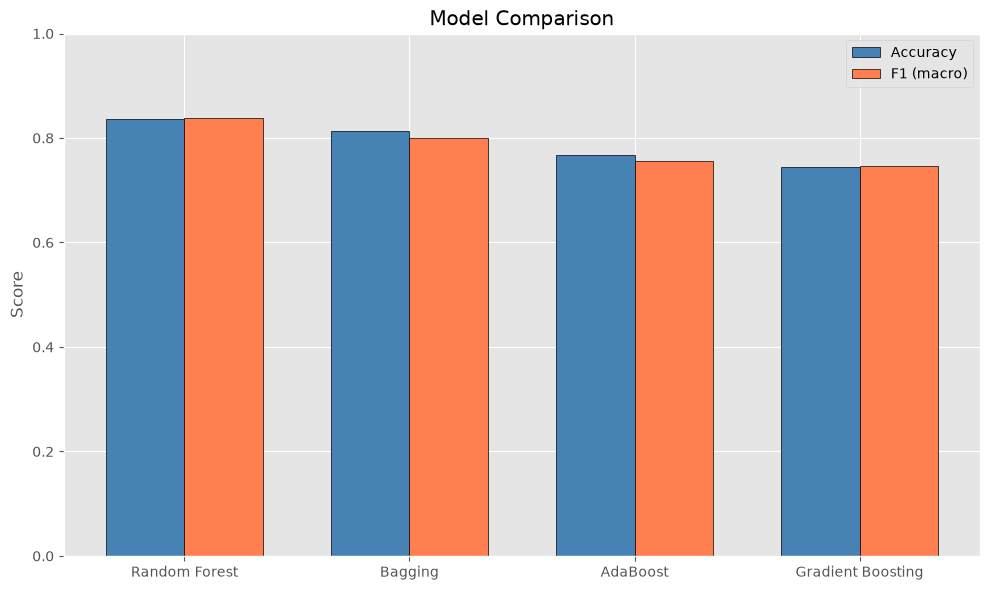

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = range(len(comparison))
ax.bar(x_pos, comparison['Accuracy'], width=0.35, label='Accuracy', color='steelblue', edgecolor='black')
ax.bar([p + 0.35 for p in x_pos], comparison['F1 (macro)'], width=0.35, label='F1 (macro)', color='coral', edgecolor='black')
ax.set_xticks([p + 0.175 for p in x_pos])
ax.set_xticklabels(comparison['Model'])
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Interview Questions

### Q1: Explain Bagging and Boosting methods. How do they differ?

**Bagging (Bootstrap Aggregating):**
- Trains multiple models independently on random bootstrap samples of training data
- Each model is trained in parallel
- Final prediction is majority vote (classification) or average (regression)
- **Key benefit:** Reduces variance, prevents overfitting
- **Example:** Random Forest = Bagging + random feature selection

**Boosting:**
- Trains models sequentially, each new model corrects errors of previous models
- Misclassified samples get higher weights
- Final prediction is weighted combination of all models
- **Key benefit:** Reduces bias, improves accuracy on hard examples
- **Examples:** AdaBoost, Gradient Boosting, XGBoost

**Key Differences:**
| Aspect | Bagging | Boosting |
|--------|---------|----------|
| Training | Parallel | Sequential |
| Focus | Reduce variance | Reduce bias |
| Weighting | Equal weight per model | Weighted by performance |
| Data sampling | Bootstrap samples | Weighted samples |
| Overfitting risk | Lower | Higher |
| Best when | High variance (complex models) | High bias (weak learners) |

### Q2: How to handle class imbalance in data?

1. **Resampling:** Oversampling minority (SMOTE) or undersampling majority
2. **Class weights:** Assign higher weights to minority class in loss function
3. **Ensemble methods:** Use balanced random forest or boosting with weights
4. **Synthetic data:** SMOTE creates synthetic minority samples
5. **Evaluation:** Use precision, recall, F1 instead of accuracy
6. **Threshold tuning:** Adjust decision threshold for better minority recall

## Conclusion

- Random Forest achieved strong classification performance on glass types
- Al, Mg, and RI are the most important features for glass classification
- Bagging and Boosting both performed well, with Gradient Boosting showing competitive results
- Model is ready for deployment as a glass type identification system